In [1]:
import json
import math
import random
import re
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from tqdm import tqdm

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from rouge_score import rouge_scorer
from bert_score import score as bertscore_score

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass
class Config:
    train_csv: str = r"C:\\bakis\\duomenys\\samsum-train.csv"
    val_csv: str = r"C:\\bakis\\duomenys\\samsum-validation.csv"
    test_csv: str = r"C:\\bakis\\duomenys\\samsum-test.csv"

    text_column: str = "dialogue"
    summary_column: str = "summary"

    output_dir: str = r"C:\\bakis\\PALYGINIMAS\\encoder_decoder"

    use_train_subset: bool = True
    train_subset_size: int = 5000
    subset_random_state: int = 42

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # tokenizacija / sekų ilgiai
    min_freq: int = 2
    max_generation_len: int = 80
    max_src_len: int = 512
    max_tgt_len: int = 80

    # modelis
    d_model: int = 512
    num_heads: int = 4
    num_encoder_layers: int = 3
    num_decoder_layers: int = 3
    d_ff: int = 1024
    dropout: float = 0.1

    # mokymas
    batch_size: int = 16
    num_epochs: int = 20
    lr: float = 1e-4
    weight_decay: float = 1e-5
    grad_clip: float = 1.0

    # early stopping
    patience: int = 3

    # output
    save_predictions_csv: bool = True
    make_plots: bool = True
    dpi: int = 160

    # bertscore
    bertscore_model_type: str = "bert-base-uncased"
    bertscore_lang: str = "en"
    compute_bertscore_on_test: bool = True
    bertscore_batch_size: int = 16

cfg = Config()
cfg

Config(train_csv='C:\\\\bakis\\\\duomenys\\\\samsum-train.csv', val_csv='C:\\\\bakis\\\\duomenys\\\\samsum-validation.csv', test_csv='C:\\\\bakis\\\\duomenys\\\\samsum-test.csv', text_column='dialogue', summary_column='summary', output_dir='C:\\\\bakis\\\\PALYGINIMAS\\\\encoder_decoder', use_train_subset=True, train_subset_size=5000, subset_random_state=42, seed=42, device='cuda', min_freq=2, max_generation_len=80, max_src_len=512, max_tgt_len=80, d_model=512, num_heads=4, num_encoder_layers=3, num_decoder_layers=3, d_ff=1024, dropout=0.1, batch_size=16, num_epochs=20, lr=0.0001, weight_decay=1e-05, grad_clip=1.0, patience=3, save_predictions_csv=True, make_plots=True, dpi=160, bertscore_model_type='bert-base-uncased', bertscore_lang='en', compute_bertscore_on_test=True, bertscore_batch_size=16)

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


def ensure_dir(path):
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def simple_tokenize(text):
    text = normalize_text(text).lower()
    # žodžiai + skyryba kaip atskiri tokenai
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def word_count(text):
    text = normalize_text(text)
    return len(text.split()) if text else 0


def safe_mean(values):
    values = list(values)
    return float(np.mean(values)) if len(values) > 0 else 0.0

In [5]:
def load_single_dataset(csv_path, cfg):
    df = pd.read_csv(csv_path)

    if cfg.text_column not in df.columns:
        raise ValueError(f"Nerastas teksto stulpelis: {cfg.text_column}")
    if cfg.summary_column not in df.columns:
        raise ValueError(f"Nerastas santraukos stulpelis: {cfg.summary_column}")

    df = df[[cfg.text_column, cfg.summary_column]].copy()
    df[cfg.text_column] = df[cfg.text_column].apply(normalize_text)
    df[cfg.summary_column] = df[cfg.summary_column].apply(normalize_text)

    df = df[
        (df[cfg.text_column] != "") &
        (df[cfg.summary_column] != "")
    ].reset_index(drop=True)

    return df


def maybe_take_train_subset(df, cfg):
    if not cfg.use_train_subset:
        return df.reset_index(drop=True)

    subset_size = min(cfg.train_subset_size, len(df))
    return df.sample(n=subset_size, random_state=cfg.subset_random_state).reset_index(drop=True)


full_train_df = load_single_dataset(cfg.train_csv, cfg)
val_df = load_single_dataset(cfg.val_csv, cfg)
test_df = load_single_dataset(cfg.test_csv, cfg)

train_df = maybe_take_train_subset(full_train_df, cfg)

print("Full train:", len(full_train_df))
print("Used train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Full train: 14731
Used train: 5000
Validation: 818
Test: 819


In [6]:
def print_dataset_stats(df, cfg, name):
    source_lengths = df[cfg.text_column].apply(word_count)
    summary_lengths = df[cfg.summary_column].apply(word_count)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Samples: {len(df)}")
    print(f"Avg source words:  {source_lengths.mean():.2f}")
    print(f"Avg summary words: {summary_lengths.mean():.2f}")

print_dataset_stats(train_df, cfg, "TRAIN")
print_dataset_stats(val_df, cfg, "VALIDATION")
print_dataset_stats(test_df, cfg, "TEST")


TRAIN
-----
Samples: 5000
Avg source words:  95.82
Avg summary words: 20.56

VALIDATION
----------
Samples: 818
Avg source words:  91.64
Avg summary words: 20.28

TEST
----
Samples: 819
Avg source words:  95.51
Avg summary words: 20.02


In [7]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3


class Vocab:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.token_to_idx = {
            PAD_TOKEN: PAD_IDX,
            UNK_TOKEN: UNK_IDX,
            BOS_TOKEN: BOS_IDX,
            EOS_TOKEN: EOS_IDX,
        }
        self.idx_to_token = {idx: tok for tok, idx in self.token_to_idx.items()}

    def build(self, tokenized_texts):
        counter = Counter()
        for tokens in tokenized_texts:
            counter.update(tokens)

        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token_to_idx:
                idx = len(self.token_to_idx)
                self.token_to_idx[token] = idx
                self.idx_to_token[idx] = token

    def encode(self, tokens):
        return [self.token_to_idx.get(tok, UNK_IDX) for tok in tokens]

    def decode(self, ids, skip_special_tokens=True):
        tokens = []
        for idx in ids:
            tok = self.idx_to_token.get(int(idx), UNK_TOKEN)
            if skip_special_tokens and tok in {PAD_TOKEN, BOS_TOKEN, EOS_TOKEN}:
                continue
            tokens.append(tok)
        return tokens

    def __len__(self):
        return len(self.token_to_idx)

In [8]:
train_source_tokens = [simple_tokenize(x)[:cfg.max_src_len] for x in train_df[cfg.text_column]]
train_target_tokens = [simple_tokenize(x)[:cfg.max_tgt_len] for x in train_df[cfg.summary_column]]

vocab = Vocab(min_freq=cfg.min_freq)
vocab.build(train_source_tokens + train_target_tokens)

print("Vocab size:", len(vocab))

Vocab size: 12224


In [9]:
class SummarizationDataset(Dataset):
    def __init__(self, df, vocab, cfg):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        src_text = row[self.cfg.text_column]
        tgt_text = row[self.cfg.summary_column]

        src_tokens = simple_tokenize(src_text)[:self.cfg.max_src_len]
        tgt_tokens = simple_tokenize(tgt_text)[:self.cfg.max_tgt_len]

        src_ids = self.vocab.encode(src_tokens)
        tgt_ids = [BOS_IDX] + self.vocab.encode(tgt_tokens) + [EOS_IDX]

        return {
            "source_text": src_text,
            "target_text": tgt_text,
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
        }


def pad_sequences(sequences, pad_value=0):
    max_len = max(len(seq) for seq in sequences)
    padded = []
    lengths = []
    for seq in sequences:
        lengths.append(len(seq))
        padded.append(seq + [pad_value] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


def collate_fn(batch):
    src_ids = [item["src_ids"] for item in batch]
    tgt_ids = [item["tgt_ids"] for item in batch]

    src_padded, src_lengths = pad_sequences(src_ids, pad_value=PAD_IDX)
    tgt_padded, tgt_lengths = pad_sequences(tgt_ids, pad_value=PAD_IDX)

    return {
        "source_texts": [item["source_text"] for item in batch],
        "target_texts": [item["target_text"] for item in batch],
        "src_ids": src_padded,
        "src_lengths": src_lengths,
        "tgt_ids": tgt_padded,
        "tgt_lengths": tgt_lengths,
    }


train_dataset = SummarizationDataset(train_df, vocab, cfg)
val_dataset = SummarizationDataset(val_df, vocab, cfg)
test_dataset = SummarizationDataset(test_df, vocab, cfg)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.q_proj(query)
        K = self.k_proj(key)
        V = self.v_proj(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.out_proj(context)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        self_attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))

        return x


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model)

    def forward(self, src_ids, src_mask):
        x = self.embedding(src_ids) * self.scale
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, src_mask)

        return x


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model)

    def forward(self, tgt_ids, enc_out, tgt_mask, src_mask):
        x = self.embedding(tgt_ids) * self.scale
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask, src_mask)

        logits = self.fc_out(x)
        return logits


class TransformerSummarizer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_encoder_layers, num_decoder_layers, d_ff, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_layers=num_encoder_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
        )

        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_layers=num_decoder_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
        )

    def make_src_mask(self, src_ids):
        # [B, 1, 1, src_len]
        return (src_ids != PAD_IDX).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt_ids):
        batch_size, tgt_len = tgt_ids.shape

        pad_mask = (tgt_ids != PAD_IDX).unsqueeze(1).unsqueeze(2)   # [B,1,1,T]
        causal_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt_ids.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(1)         # [1,1,T,T]

        return pad_mask & causal_mask

    def forward(self, src_ids, tgt_ids):
        src_mask = self.make_src_mask(src_ids)
        tgt_mask = self.make_tgt_mask(tgt_ids)

        enc_out = self.encoder(src_ids, src_mask)
        logits = self.decoder(tgt_ids, enc_out, tgt_mask, src_mask)

        return logits

    @torch.no_grad()
    def generate(self, src_ids, max_len=80):
        self.eval()
        batch_size = src_ids.size(0)

        src_mask = self.make_src_mask(src_ids)
        enc_out = self.encoder(src_ids, src_mask)

        generated = torch.full(
            (batch_size, 1),
            BOS_IDX,
            dtype=torch.long,
            device=src_ids.device
        )

        finished = torch.zeros(batch_size, dtype=torch.bool, device=src_ids.device)

        for _ in range(max_len):
            tgt_mask = self.make_tgt_mask(generated)
            logits = self.decoder(generated, enc_out, tgt_mask, src_mask)

            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)

            finished |= (next_token.squeeze(1) == EOS_IDX)
            if finished.all():
                break

        return generated

In [11]:
model = TransformerSummarizer(
    vocab_size=len(vocab),
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_encoder_layers=cfg.num_encoder_layers,
    num_decoder_layers=cfg.num_decoder_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(cfg.device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

print(model)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model))

TransformerSummarizer(
  (encoder): TransformerEncoder(
    (embedding): Embedding(12224, 512, padding_idx=0)
    (pos_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (q_proj): Linear(in_features=512, out_features=512, bias=True)
          (k_proj): Linear(in_features=512, out_features=512, bias=True)
          (v_proj): Linear(in_features=512, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): PositionwiseFeedForward(
          (net): Sequential(
            (0): Linear(in_features=512, out_features=1024, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=1024, out_features=512, bias=True)
          )
        )
        (norm1): LayerNorm((512,), eps=1e

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(loader, start=1):
        src_ids = batch["src_ids"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        decoder_input = tgt_ids[:, :-1]
        target_output = tgt_ids[:, 1:]

        optimizer.zero_grad()

        outputs = model(
            src_ids=src_ids,
            tgt_ids=decoder_input
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            target_output.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0 or batch_idx == len(loader):
            print(f"    batch {batch_idx}/{len(loader)} | loss={loss.item():.4f}")

    return total_loss / max(len(loader), 1)

In [13]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        src_ids = batch["src_ids"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        decoder_input = tgt_ids[:, :-1]
        target_output = tgt_ids[:, 1:]

        outputs = model(
            src_ids=src_ids,
            tgt_ids=decoder_input
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            target_output.reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

In [14]:
def compute_rouge(pred_df):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    rouge1_p, rouge1_r, rouge1_f = [], [], []
    rouge2_p, rouge2_r, rouge2_f = [], [], []
    rougeL_p, rougeL_r, rougeL_f = [], [], []

    for _, row in pred_df.iterrows():
        reference = row["reference_summary"]
        prediction = row["predicted_summary"]

        scores = scorer.score(reference, prediction)

        r1 = scores["rouge1"]
        r2 = scores["rouge2"]
        rl = scores["rougeL"]

        rouge1_p.append(r1.precision)
        rouge1_r.append(r1.recall)
        rouge1_f.append(r1.fmeasure)

        rouge2_p.append(r2.precision)
        rouge2_r.append(r2.recall)
        rouge2_f.append(r2.fmeasure)

        rougeL_p.append(rl.precision)
        rougeL_r.append(rl.recall)
        rougeL_f.append(rl.fmeasure)

    pred_df = pred_df.copy()
    pred_df["rouge1_precision"] = rouge1_p
    pred_df["rouge1_recall"] = rouge1_r
    pred_df["rouge1_f1"] = rouge1_f

    pred_df["rouge2_precision"] = rouge2_p
    pred_df["rouge2_recall"] = rouge2_r
    pred_df["rouge2_f1"] = rouge2_f

    pred_df["rougeL_precision"] = rougeL_p
    pred_df["rougeL_recall"] = rougeL_r
    pred_df["rougeL_f1"] = rougeL_f

    return pred_df

In [15]:
def compute_bertscore(pred_df, cfg):
    refs = pred_df["reference_summary"].fillna("").astype(str).tolist()
    preds = pred_df["predicted_summary"].fillna("").astype(str).tolist()

    P, R, F1 = bertscore_score(
        preds,
        refs,
        lang=cfg.bertscore_lang,
        model_type=cfg.bertscore_model_type,
        batch_size=cfg.bertscore_batch_size,
        verbose=True,
        device=cfg.device
    )

    pred_df["bertscore_precision"] = P.cpu().numpy()
    pred_df["bertscore_recall"] = R.cpu().numpy()
    pred_df["bertscore_f1"] = F1.cpu().numpy()

    return pred_df

In [16]:
@torch.no_grad()
def decode_generated_tokens(token_ids, vocab):
    tokens = []
    for idx in token_ids:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in {PAD_IDX, BOS_IDX}:
            continue
        tokens.append(vocab.idx_to_token.get(idx, UNK_TOKEN))
    return " ".join(tokens).strip()


@torch.no_grad()
def generate_predictions(model, loader, vocab, cfg, split_name):
    model.eval()
    rows = []

    for batch in loader:
        src_ids = batch["src_ids"].to(cfg.device)

        generated = model.generate(
            src_ids=src_ids,
            max_len=cfg.max_generation_len
        )

        for i in range(src_ids.size(0)):
            prediction = decode_generated_tokens(generated[i].tolist(), vocab)

            source_text = batch["source_texts"][i]
            reference = batch["target_texts"][i]

            rows.append({
                "split": split_name,
                "id": len(rows),
                "source_text": source_text,
                "reference_summary": reference,
                "predicted_summary": prediction,
                "source_words": word_count(source_text),
                "reference_words": word_count(reference),
                "prediction_words": word_count(prediction),
            })

    return pd.DataFrame(rows)

In [17]:
def build_metrics(pred_df):
    metrics = {
        "num_samples": int(len(pred_df)),
        "rouge1_f1_mean": safe_mean(pred_df["rouge1_f1"].values),
        "rouge2_f1_mean": safe_mean(pred_df["rouge2_f1"].values),
        "rougeL_f1_mean": safe_mean(pred_df["rougeL_f1"].values),

        "rouge1_precision_mean": safe_mean(pred_df["rouge1_precision"].values),
        "rouge1_recall_mean": safe_mean(pred_df["rouge1_recall"].values),

        "rouge2_precision_mean": safe_mean(pred_df["rouge2_precision"].values),
        "rouge2_recall_mean": safe_mean(pred_df["rouge2_recall"].values),

        "rougeL_precision_mean": safe_mean(pred_df["rougeL_precision"].values),
        "rougeL_recall_mean": safe_mean(pred_df["rougeL_recall"].values),

        "source_words_mean": safe_mean(pred_df["source_words"].values),
        "reference_words_mean": safe_mean(pred_df["reference_words"].values),
        "prediction_words_mean": safe_mean(pred_df["prediction_words"].values),
    }

    if "bertscore_precision" in pred_df.columns:
        metrics["bertscore_precision_mean"] = float(pred_df["bertscore_precision"].mean())
        metrics["bertscore_recall_mean"] = float(pred_df["bertscore_recall"].mean())
        metrics["bertscore_f1_mean"] = float(pred_df["bertscore_f1"].mean())
        
    return metrics


def print_metrics(metrics, split_name):
    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Samples:               {metrics['num_samples']}")
    print(f"ROUGE-1 F1:            {metrics['rouge1_f1_mean']:.4f}")
    print(f"ROUGE-2 F1:            {metrics['rouge2_f1_mean']:.4f}")
    print(f"ROUGE-L F1:            {metrics['rougeL_f1_mean']:.4f}")
    print(f"ROUGE-1 Precision:     {metrics['rouge1_precision_mean']:.4f}")
    print(f"ROUGE-1 Recall:        {metrics['rouge1_recall_mean']:.4f}")
    print(f"ROUGE-2 Precision:     {metrics['rouge2_precision_mean']:.4f}")
    print(f"ROUGE-2 Recall:        {metrics['rouge2_recall_mean']:.4f}")
    print(f"ROUGE-L Precision:     {metrics['rougeL_precision_mean']:.4f}")
    print(f"ROUGE-L Recall:        {metrics['rougeL_recall_mean']:.4f}")
    print(f"Avg source words:      {metrics['source_words_mean']:.2f}")
    print(f"Avg reference words:   {metrics['reference_words_mean']:.2f}")
    print(f"Avg prediction words:  {metrics['prediction_words_mean']:.2f}")

In [18]:
def save_dataframe(df, path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False, encoding="utf-8")
    elif path.suffix.lower() == ".json":
        df.to_json(path, orient="records", force_ascii=False, indent=2)
    else:
        raise ValueError(f"Nepalaikomas failo tipas: {path}")


def save_metrics(metrics, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)


def save_training_plot(history, output_path, dpi=160):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

START TRAINING

===== Epoch 1/20 =====
    batch 20/313 | loss=7.7177
    batch 40/313 | loss=6.9701
    batch 60/313 | loss=6.6640
    batch 80/313 | loss=6.5704
    batch 100/313 | loss=6.5833
    batch 120/313 | loss=6.3579
    batch 140/313 | loss=6.1587
    batch 160/313 | loss=6.2310
    batch 180/313 | loss=5.9169
    batch 200/313 | loss=6.1695
    batch 220/313 | loss=6.2438
    batch 240/313 | loss=5.9979
    batch 260/313 | loss=6.0326
    batch 280/313 | loss=6.2999
    batch 300/313 | loss=6.0442
    batch 313/313 | loss=5.9893
Epoch 01/20 | train_loss=6.4618 | val_loss=5.7697 | time=34.7s
  -> best model saved

===== Epoch 2/20 =====
    batch 20/313 | loss=6.0844
    batch 40/313 | loss=5.7122
    batch 60/313 | loss=5.9347
    batch 80/313 | loss=5.7432
    batch 100/313 | loss=5.7368
    batch 120/313 | loss=5.5532
    batch 140/313 | loss=5.7557
    batch 160/313 | loss=5.6539
    batch 180/313 | loss=5.4671
    batch 200/313 | loss=5.6155
    batch 220/313 | loss=5.8

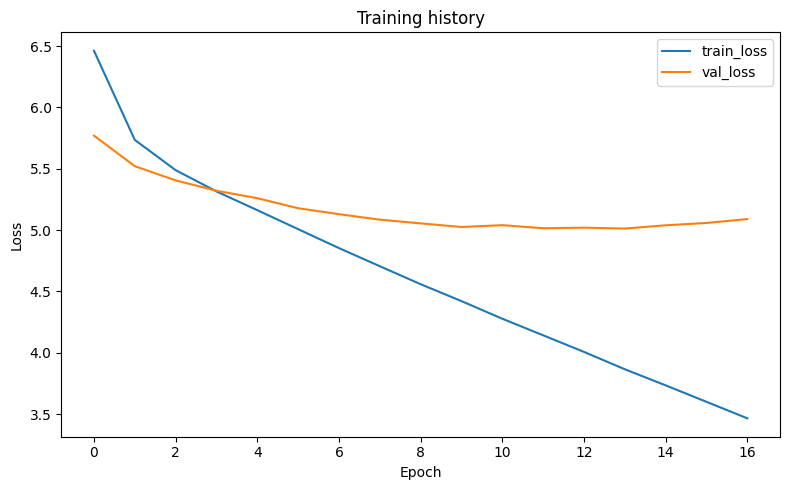

In [18]:
output_dir = ensure_dir(cfg.output_dir)
model_dir = ensure_dir(output_dir / "model")

history = {
    "train_loss": [],
    "val_loss": [],
    "epoch_time_sec": []
}

best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

start_time = time.time()

print("START TRAINING")

for epoch in range(1, cfg.num_epochs + 1):
    epoch_start = time.time()

    print(f"\n===== Epoch {epoch}/{cfg.num_epochs} =====")

    train_loss = train_one_epoch(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=cfg.device,
    grad_clip=cfg.grad_clip,
    )

    val_loss = evaluate_loss(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
    )

    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epoch_time_sec"].append(epoch_time)

    print(f"Epoch {epoch:02d}/{cfg.num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": asdict(cfg),
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": history,
        "vocab_token_to_idx": vocab.token_to_idx,
        }

        torch.save(checkpoint, model_dir / "best_model.pt")
        print("  -> best model saved")
    else:
        patience_counter += 1
        print(f"  -> no improvement ({patience_counter}/{cfg.patience})")

        if patience_counter >= cfg.patience:
            print("Early stopping triggered.")
            break

total_time_sec = time.time() - start_time

training_summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_completed": len(history["train_loss"]),
    "total_training_time_sec": total_time_sec,
    "total_training_time_min": total_time_sec / 60,
    "history": history,
}

with open(model_dir / "training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)

print(f"\nTotal training time: {total_time_sec / 60:.2f} min")
print(f"Training summary saved to: {output_dir / 'training_summary.json'}")

save_training_plot(history, model_dir / "training_history.png", dpi=cfg.dpi)

In [19]:
checkpoint = torch.load(model_dir / "best_model.pt", map_location=cfg.device)

loaded_vocab = Vocab(min_freq=cfg.min_freq)
loaded_vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
loaded_vocab.idx_to_token = {idx: tok for tok, idx in loaded_vocab.token_to_idx.items()}

loaded_model = TransformerSummarizer(
    vocab_size=len(loaded_vocab),
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_encoder_layers=cfg.num_encoder_layers,
    num_decoder_layers=cfg.num_decoder_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(cfg.device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Loaded best model from epoch:", checkpoint["best_epoch"])
print("Best val loss:", checkpoint["best_val_loss"])

C:\Users\User\AppData\Local\Temp\ipykernel_11768\1914260880.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / "best_model.pt", map_loca

Loaded best model from epoch: 14
Best val loss: 5.012491473784814


In [27]:
all_results = {}

split_map = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader,
}

for split_name, loader in split_map.items():
    print(f"\nProcessing {split_name}...")

    split_dir = ensure_dir(output_dir / split_name)

    pred_df = generate_predictions(
        model=loaded_model,
        loader=loader,
        vocab=loaded_vocab,
        cfg=cfg,
        split_name=split_name
    )

    pred_df = compute_rouge(pred_df)

    if split_name == "test" and cfg.compute_bertscore_on_test:
        pred_df = compute_bertscore(pred_df, cfg)

    metrics = build_metrics(pred_df)

    pred_df.to_csv(split_dir / "predictions.csv", index=False, encoding="utf-8")

    with open(split_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print(metrics)

print("\nDone.")


Processing train...
{'num_samples': 5000, 'rouge1_f1_mean': 0.30944064632911994, 'rouge2_f1_mean': 0.11002371862140073, 'rougeL_f1_mean': 0.26274938977816353, 'rouge1_precision_mean': 0.39227632060666223, 'rouge1_recall_mean': 0.2831110407075607, 'rouge2_precision_mean': 0.14201490210382084, 'rouge2_recall_mean': 0.10065353648419972, 'rougeL_precision_mean': 0.32999927848380894, 'rougeL_recall_mean': 0.24240923431118508, 'source_words_mean': 95.82, 'reference_words_mean': 20.5566, 'prediction_words_mean': 20.4188}

Processing val...
{'num_samples': 818, 'rouge1_f1_mean': 0.24548998848743162, 'rouge2_f1_mean': 0.05572672918204887, 'rougeL_f1_mean': 0.2034189154791202, 'rouge1_precision_mean': 0.33245465058068274, 'rouge1_recall_mean': 0.21941217213380584, 'rouge2_precision_mean': 0.07836367037514123, 'rouge2_recall_mean': 0.04980210020983463, 'rougeL_precision_mean': 0.2715557279961921, 'rougeL_recall_mean': 0.18406057329164757, 'source_words_mean': 91.64180929095355, 'reference_words_

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10501.59it/s]
BertModel LOAD REPORT from: b

calculating scores...
computing bert embedding.


100%|██████████| 103/103 [00:02<00:00, 39.67it/s]


computing greedy matching.


100%|██████████| 52/52 [00:00<00:00, 154.72it/s]

done in 2.94 seconds, 278.67 sentences/sec
{'num_samples': 819, 'rouge1_f1_mean': 0.23760757136677305, 'rouge2_f1_mean': 0.05673831026392149, 'rougeL_f1_mean': 0.20094086284480026, 'rouge1_precision_mean': 0.3239917706305294, 'rouge1_recall_mean': 0.211624135808057, 'rouge2_precision_mean': 0.07966024335693848, 'rouge2_recall_mean': 0.05024844351716728, 'rougeL_precision_mean': 0.27121935140860093, 'rougeL_recall_mean': 0.1805063357651898, 'source_words_mean': 95.5079365079365, 'reference_words_mean': 20.017094017094017, 'prediction_words_mean': 17.803418803418804, 'bertscore_precision_mean': 0.5469340085983276, 'bertscore_recall_mean': 0.48664435744285583, 'bertscore_f1_mean': 0.5126466751098633}

Done.


In [19]:
test_predictions = pd.read_csv(Path(cfg.output_dir) / "test" / "predictions.csv")
test_predictions[["source_text", "reference_summary", "predicted_summary", "rouge1_f1", "rougeL_f1"]].head(10)

,source_text,reference_summary,predicted_summary,rouge1_f1,rougeL_f1
0,"Hannah: Hey, do you have Betty's number? Amand...",Hannah needs Betty's number but Amanda doesn't...,hannah and hannah are going to the cinema to t...,0.176471,0.117647
1,Eric: MACHINE! Rob: That's so gr8! Eric: I kno...,Eric and Rob are going to watch a stand-up on ...,eric will watch the movie on sunday .,0.315789,0.315789
2,"Lenny: Babe, can you help me with something? B...",Lenny can't decide which trousers to buy. Bob ...,bob has a photo of the first steps .,0.162162,0.108108
3,"Will: hey babe, what do you want for dinner to...",Emma will be home soon and she will let Will k...,emma will pick up from home tonight .,0.333333,0.333333
4,"Ollie: Hi , are you in Warsaw Jane: yes, just ...",Jane is in Warsaw. Ollie and Jane has a party....,jane is going to a party on friday at the part...,0.360656,0.262295
5,"Benjamin: Hey guys, what are we doing with the...",Hilary has the keys to the apartment. Benjamin...,daniel and daniel are going to the meeting for...,0.379747,0.227848
6,Max: Know any good sites to buy clothes from? ...,Payton provides Max with websites selling clot...,max has sent a new dress from max . max will b...,0.127660,0.085106
7,Rita: I'm so bloody tired. Falling asleep at w...,Rita and Tina are bored at work and have still...,tina ' s sister is not at work . tina ' s frie...,0.222222,0.222222
8,"Beatrice: I am in town, shopping. They have ni...","Beatrice wants to buy Leo a scarf, but he does...",leo is going to get a drink of the gym in the ...,0.150943,0.113208
9,Ivan: hey eric Eric: yeah man Ivan: so youre c...,Eric doesn't know if his parents let him go to...,eric will come to eric ' s place at home .,0.266667,0.200000


In [20]:
def load_saved_transformer_model(model_path, cfg):
    checkpoint = torch.load(model_path, map_location=cfg.device)

    vocab = Vocab(min_freq=cfg.min_freq)
    vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
    vocab.idx_to_token = {idx: tok for tok, idx in vocab.token_to_idx.items()}

    model = TransformerSummarizer(
        vocab_size=len(vocab),
        d_model=cfg.d_model,
        num_heads=cfg.num_heads,
        num_encoder_layers=cfg.num_encoder_layers,
        num_decoder_layers=cfg.num_decoder_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(cfg.device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, vocab, checkpoint


@torch.no_grad()
def predict_with_saved_transformer(model_path, text, cfg):
    model, vocab, checkpoint = load_saved_transformer_model(model_path, cfg)

    tokens = simple_tokenize(text)[:cfg.max_src_len]
    src_ids = vocab.encode(tokens)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=cfg.device).unsqueeze(0)

    generated = model.generate(src_tensor, max_len=cfg.max_generation_len)
    prediction = decode_generated_tokens(generated[0].tolist(), vocab)

    return prediction

In [21]:
sample_text = """Amanda: Are we still meeting tomorrow?
John: Yes, at 10 in the library.
Amanda: Great, I will bring the notes.
John: Perfect, see you there."""

summary = predict_with_saved_transformer(
    Path(cfg.output_dir) / "model" / "best_model.pt",
    sample_text,
    cfg
)
print(summary)

C:\Users\User\AppData\Local\Temp\ipykernel_5020\390198520.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=cfg.device)


john and john are meeting tomorrow at the station . john will bring the meeting .


In [22]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return total, trainable, non_trainable

total, trainable, non_trainable = count_parameters(model)

print(f"Iš viso parametrų: {total:,}")
print(f"Mokomų parametrų: {trainable:,}")
print(f"Nemokomų parametrų: {non_trainable:,}")

Iš viso parametrų: 34,559,936
Mokomų parametrų: 34,559,936
Nemokomų parametrų: 0
